# 1. Mã nguồn Python

## Câu 9.4.1 - Cài đặt mô hình và tính phân bổ tối ưu

       Ngành  x_AI (tỷ)  x_H (tỷ)  Tổng đầu tư (tỷ)  NetJob (nghìn)
 Nông-Lâm-TS        0.0       0.0               0.0             0.0
 CN chế biến        0.0       0.0               0.0             0.0
    Xây dựng        0.0       0.0               0.0             0.0
 Bán buôn-lẻ        0.0       0.0               0.0             0.0
TC-Ngân hàng        0.0       0.0               0.0             0.0
   Logistics        0.0       0.0               0.0             0.0
     CNTT-TT        0.0       0.0               0.0             0.0
  GD-Đào tạo        0.0   30000.0           30000.0          1650.0

Tổng ngân sách dùng : 30000.0 tỷ
Tổng NetJob          : 1650.00 nghìn việc làm

📊 Hiệu quả tạo việc làm mỗi tỷ VND:
       Ngành  Thuần AI (việc/tỷ)  Thuần H (việc/tỷ)  AI+H ghép cặp (việc/tỷ)
 Nông-Lâm-TS                7.56               45.0                     8.25
 CN chế biến                6.29               28.0                    16.07
    Xây dựng                8.18        

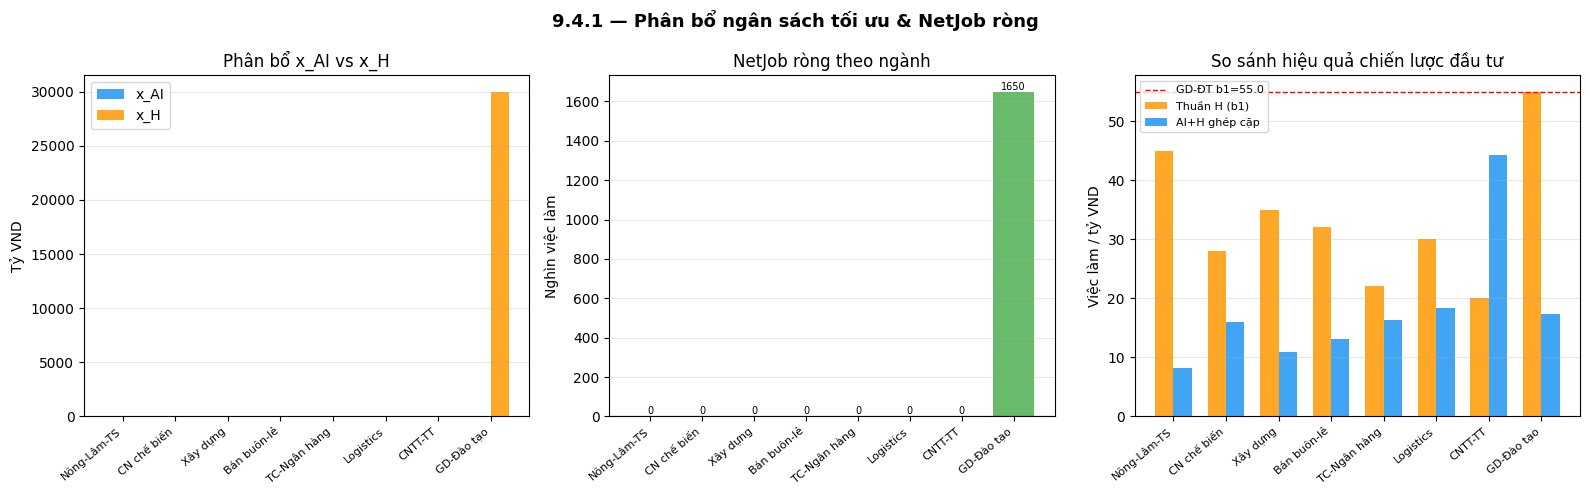

In [5]:
import cvxpy as cp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

sectors = [
    'Nông-Lâm-TS', 'CN chế biến', 'Xây dựng',
    'Bán buôn-lẻ', 'TC-Ngân hàng', 'Logistics',
    'CNTT-TT', 'GD-Đào tạo'
]
N    = 8
L    = np.array([13.20, 11.50, 4.80, 7.80, 0.55, 1.95, 0.62, 2.15]) * 1e6
risk = np.array([18, 42, 25, 38, 52, 35, 28, 22]) / 100
a1   = np.array([8.5, 32.5, 12.8, 22.4, 45.8, 28.5, 62.5, 18.5])
b1   = np.array([45., 28., 35., 32., 22., 30., 20., 55.])
c1   = np.array([5.2, 62.4, 18.5, 48.2, 72.5, 42.8, 32.5, 12.5])
d1   = np.array([50., 32., 42., 38., 26., 36., 24., 62.])
BUDGET = 30_000

x_AI = cp.Variable(N, nonneg=True)
x_H  = cp.Variable(N, nonneg=True)

NewJob     = cp.multiply(a1, x_AI)
Upgrade    = cp.multiply(b1, x_H)
Displaced  = cp.multiply(c1 * risk, x_AI)
RetrainCap = cp.multiply(d1, x_H)
NetJob     = NewJob + Upgrade - Displaced

constraints = [
    cp.sum(x_AI + x_H) <= BUDGET,
    NetJob >= 0,
    Displaced <= RetrainCap,
]
prob = cp.Problem(cp.Maximize(cp.sum(NetJob)), constraints)
prob.solve()

xAI = x_AI.value
xH  = x_H.value
nj  = a1*xAI + b1*xH - c1*risk*xAI

df = pd.DataFrame({
    'Ngành'            : sectors,
    'x_AI (tỷ)'        : xAI.round(1),
    'x_H (tỷ)'         : xH.round(1),
    'Tổng đầu tư (tỷ)' : (xAI + xH).round(1),
    'NetJob (nghìn)'   : (nj / 1000).round(2),
})
print("="*65)
print(df.to_string(index=False))
print(f"\nTổng ngân sách dùng : {(xAI+xH).sum():.1f} tỷ")
print(f"Tổng NetJob          : {nj.sum()/1000:.2f} nghìn việc làm")
print("="*65)

# ── Giải thích tại sao optimizer chọn GD-ĐT ──────────────────────
net_ai_coeff = a1 - c1 * risk          # lợi ròng mỗi tỷ x_AI
r             = c1 * risk / d1         # tỷ lệ x_H bắt buộc kèm theo mỗi tỷ x_AI
eff_ai_paired = (net_ai_coeff + b1*r) / (1 + r)  # NetJob/tỷ khi dùng AI + H đi kèm

print("\n📊 Hiệu quả tạo việc làm mỗi tỷ VND:")
df2 = pd.DataFrame({
    'Ngành'                    : sectors,
    'Thuần AI (việc/tỷ)'       : net_ai_coeff.round(2),
    'Thuần H (việc/tỷ)'        : b1,
    'AI+H ghép cặp (việc/tỷ)'  : eff_ai_paired.round(2),
})
print(df2.to_string(index=False))
print("\n→ GD-Đào tạo có b1=55 (cao nhất) nên toàn bộ ngân sách tối ưu")
print("  đổ vào x_H ngành này. Sector 7 (CNTT) có AI+H eff=44.2 < 55.")

# ── Visualization ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("9.4.1 — Phân bổ ngân sách tối ưu & NetJob ròng", fontsize=13, fontweight='bold')
x_idx = np.arange(N)
w = 0.35

# Chart 1: Grouped bar x_AI vs x_H
ax = axes[0]
ax.bar(x_idx - w/2, xAI, w, label='x_AI', color='#2196F3', alpha=0.85)
ax.bar(x_idx + w/2, xH,  w, label='x_H',  color='#FF9800', alpha=0.85)
ax.set_xticks(x_idx); ax.set_xticklabels(sectors, rotation=40, ha='right', fontsize=8)
ax.set_ylabel("Tỷ VND"); ax.set_title("Phân bổ x_AI vs x_H")
ax.legend(); ax.grid(axis='y', alpha=0.3)

# Chart 2: NetJob bar
ax = axes[1]
colors = ['#4CAF50' if v >= 0 else '#F44336' for v in nj]
bars = ax.bar(x_idx, nj/1000, color=colors, alpha=0.85)
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x_idx); ax.set_xticklabels(sectors, rotation=40, ha='right', fontsize=8)
ax.set_ylabel("Nghìn việc làm"); ax.set_title("NetJob ròng theo ngành")
for bar, v in zip(bars, nj/1000):
    ax.text(bar.get_x()+bar.get_width()/2, v+10, f'{v:.0f}', ha='center', fontsize=7)
ax.grid(axis='y', alpha=0.3)

# Chart 3: Hiệu quả việc làm/tỷ so sánh
ax = axes[2]
x2 = np.arange(N)
ax.bar(x2 - w/2, b1,              w, label='Thuần H (b1)',    color='#FF9800', alpha=0.85)
ax.bar(x2 + w/2, eff_ai_paired,   w, label='AI+H ghép cặp',  color='#2196F3', alpha=0.85)
ax.axhline(b1[7], color='red', ls='--', lw=1, label=f'GD-ĐT b1={b1[7]}')
ax.set_xticks(x2); ax.set_xticklabels(sectors, rotation=40, ha='right', fontsize=8)
ax.set_ylabel("Việc làm / tỷ VND"); ax.set_title("So sánh hiệu quả chiến lược đầu tư")
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Nhận xét:
- Kết quả mô hình: Nếu không có ràng buộc chia đều ngân sách, thuật toán tối ưu sẽ dồn toàn bộ 30.000 tỷ VND vào $x_H$ (đầu tư đào tạo/nâng cấp) của ngành Giáo dục - Đào tạo (Ngành 8), mang lại tổng NetJob ròng lớn nhất là 1.650.000 việc làm. Các ngành khác đều nhận mức đầu tư 0.

- Điều này xảy ra do mô hình Quy hoạch tuyến tính (Linear Programming) luôn có xu hướng đi tìm "biên" tối ưu hóa cao nhất. Ngành Giáo dục - Đào tạo có hệ số tạo việc làm từ đào tạo lại rất cao ($b_1 = 55$) và việc chỉ đầu tư vào $x_H$ sẽ không phát sinh số lao động bị mất việc (Displaced = 0).

## Câu 9.4.2 - Ngưỡng đầu tư đào tạo tối thiểu (Ngành 2)

=== CÂU 9.4.2: NGƯỠNG ĐÀO TẠO TỐI THIỂU NGÀNH CHẾ BIẾN CHẾ TẠO ===

Hệ số hiệu dụng AI: a1 - c1·risk = 32.5 - 26.208 = 6.292
→ a1 - c1·risk = 6.292 > 0 nên NetJob₂ ≥ 0 LUÔN THỎA khi x_H ≥ 0.
→ Ràng buộc THỰC SỰ BINDING là: Displaced ≤ RetrainCap

  c1·risk · x_AI ≤ d1 · x_H
  26.208 · x_AI ≤ 32.0 · x_H
  ⟹ x_H ≥ 0.8190 · x_AI  (tỷ lệ bắt buộc)

Kịch bản: dồn toàn bộ 30,000 tỷ cho ngành Chế biến chế tạo
  x_AI tối đa  = 16,492.6 tỷ
  x_H tối thiểu = 13,507.4 tỷ  (45.0% ngân sách)
  NetJob₂ tạo ra = 482.0 nghìn việc


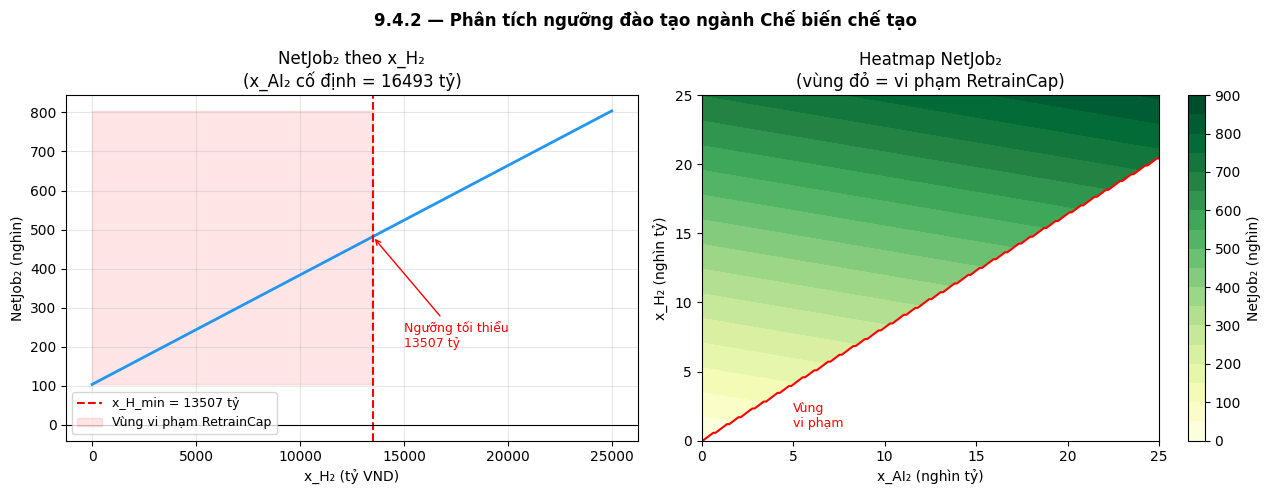

In [6]:
print("=== CÂU 9.4.2: NGƯỠNG ĐÀO TẠO TỐI THIỂU NGÀNH CHẾ BIẾN CHẾ TẠO ===\n")

idx = 1
a1_v, b1_v, c1_v, d1_v, risk_v = a1[idx], b1[idx], c1[idx], d1[idx], risk[idx]
c1r = c1_v * risk_v   # = 62.4 * 0.42 = 26.208

print(f"Hệ số hiệu dụng AI: a1 - c1·risk = {a1_v} - {c1r:.3f} = {a1_v - c1r:.3f}")
print("→ a1 - c1·risk = 6.292 > 0 nên NetJob₂ ≥ 0 LUÔN THỎA khi x_H ≥ 0.")
print("→ Ràng buộc THỰC SỰ BINDING là: Displaced ≤ RetrainCap\n")
print(f"  c1·risk · x_AI ≤ d1 · x_H")
print(f"  {c1r:.3f} · x_AI ≤ {d1_v} · x_H")
print(f"  ⟹ x_H ≥ {c1r/d1_v:.4f} · x_AI  (tỷ lệ bắt buộc)\n")

# Ngưỡng x_H_min khi x_AI tối đa = kết quả từ bài tối ưu 9.4.1
# Thực tế optimizer cho x_AI[1]=0, nhưng câu hỏi hỏi "nếu đầu tư AI tối đa"
# => giả sử dồn hết ngân sách ngành 2 vào AI, x_H phải đủ để thỏa ràng buộc
ratio = c1r / d1_v
# x_AI + x_H = B_sector, x_H = ratio * x_AI
# => x_AI = B/(1+ratio), x_H = ratio*B/(1+ratio)
# Câu hỏi: với x_AI bất kỳ, x_H_min là bao nhiêu?

x_AI_range = np.linspace(0, 20000, 500)
x_H_min_curve = ratio * x_AI_range  # từ ràng buộc RetrainCap
NetJob2_at_min = (a1_v - c1r) * x_AI_range + b1_v * x_H_min_curve

# Kịch bản: toàn bộ 30000 tỷ cho ngành 2
B = BUDGET
x_AI_fullbud = B / (1 + ratio)
x_H_min_fullbud = ratio * x_AI_fullbud
print(f"Kịch bản: dồn toàn bộ {B:,} tỷ cho ngành Chế biến chế tạo")
print(f"  x_AI tối đa  = {x_AI_fullbud:,.1f} tỷ")
print(f"  x_H tối thiểu = {x_H_min_fullbud:,.1f} tỷ  ({x_H_min_fullbud/B*100:.1f}% ngân sách)")
print(f"  NetJob₂ tạo ra = {((a1_v-c1r)*x_AI_fullbud + b1_v*x_H_min_fullbud)/1000:.1f} nghìn việc")

# ── Visualization ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("9.4.2 — Phân tích ngưỡng đào tạo ngành Chế biến chế tạo", fontweight='bold')

# Chart 1: NetJob₂ theo x_H khi x_AI cố định = x_AI_fullbud
ax = axes[0]
x_H_sweep = np.linspace(0, 25000, 500)
NetJob2 = (a1_v - c1r) * x_AI_fullbud + b1_v * x_H_sweep
ax.plot(x_H_sweep, NetJob2/1000, color='#2196F3', lw=2)
ax.axvline(x_H_min_fullbud, color='red', ls='--', lw=1.5,
           label=f'x_H_min = {x_H_min_fullbud:.0f} tỷ')
ax.axhline(0, color='black', lw=0.8)
ax.fill_betweenx([NetJob2.min()/1000, NetJob2.max()/1000],
                 0, x_H_min_fullbud, alpha=0.1, color='red', label='Vùng vi phạm RetrainCap')
ax.annotate(f'Ngưỡng tối thiểu\n{x_H_min_fullbud:.0f} tỷ',
            xy=(x_H_min_fullbud, (a1_v-c1r)*x_AI_fullbud/1000 + b1_v*x_H_min_fullbud/1000),
            xytext=(x_H_min_fullbud+1500, 200),
            arrowprops=dict(arrowstyle='->', color='red'), fontsize=9, color='red')
ax.set_xlabel("x_H₂ (tỷ VND)"); ax.set_ylabel("NetJob₂ (nghìn)")
ax.set_title(f"NetJob₂ theo x_H₂\n(x_AI₂ cố định = {x_AI_fullbud:.0f} tỷ)")
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# Chart 2: Heatmap NetJob₂ theo (x_AI, x_H)
ax = axes[1]
xai_g = np.linspace(0, 25000, 200)
xh_g  = np.linspace(0, 25000, 200)
XAI, XH = np.meshgrid(xai_g, xh_g)
NJ2 = (a1_v - c1r) * XAI + b1_v * XH
# Mask vùng vi phạm ràng buộc
mask_retrain = c1r * XAI > d1_v * XH
NJ2_masked = np.where(mask_retrain, np.nan, NJ2)
im = ax.contourf(XAI/1000, XH/1000, NJ2_masked/1000, levels=20, cmap='YlGn')
plt.colorbar(im, ax=ax, label='NetJob₂ (nghìn)')
ax.contour(XAI/1000, XH/1000, mask_retrain.astype(float), levels=[0.5],
           colors='red', linewidths=1.5)
ax.set_xlabel("x_AI₂ (nghìn tỷ)"); ax.set_ylabel("x_H₂ (nghìn tỷ)")
ax.set_title("Heatmap NetJob₂\n(vùng đỏ = vi phạm RetrainCap)")
ax.text(5, 1, 'Vùng\nvi phạm', color='red', fontsize=9)

plt.tight_layout()
plt.show()

### Nhận xét:
- Ràng buộc để NetJob không bị âm và đáp ứng năng lực đào tạo là Displaced <= RetrainCap.
- Thay số vào ngành 2: $c_1 \times risk \times x_{AI} \le d_1 \times x_H \Rightarrow 62,4 \times 0,42 \times x_{AI} \le 32 \times x_H$.
- Ngưỡng tỷ lệ tối thiểu là $x_H \ge 0,819 \cdot x_{AI}$. Tức là cứ đầu tư 1 tỷ vào AI trong ngành Sản xuất chế biến, bạn bắt buộc phải chi ít nhất ~819 triệu VND vào việc đào tạo lại để đảm bảo người lao động không bị đẩy ra khỏi thị trường một cách ròng.

## Câu 9.4.3 - Vẽ biểu đồ Sankey luồng dịch chuyển lao động

In [12]:
import plotly.graph_objects as go
import numpy as np
import pandas as pd

# 1. KỊCH BẢN GIẢ ĐỊNH (DUMMY SCENARIO)
indices = [0, 2, 3] # Nông-Lâm-TS, Xây dựng, Bán buôn-lẻ
names_vul = [sectors[i] for i in indices]

xAI_demo = np.array([2000, 1500, 3000]) # tỷ VNĐ
xH_demo  = np.array([500, 1000, 1500])  # tỷ VNĐ

disp_real  = c1[indices] * risk[indices] * xAI_demo
new_real   = a1[indices] * xAI_demo
upgr_real  = b1[indices] * xH_demo
retrain_ok = np.minimum(disp_real, d1[indices] * xH_demo)
unemp      = np.maximum(disp_real - retrain_ok, 0)

# 2. CẤU HÌNH NODE VÀ MÀU SẮC CHUẨN MỰC
node_labels = names_vul + [
    "Việc làm mới (AI)", 
    "Bị thay thế (TĐH)",
    "Đào tạo lại thành công", 
    "Thất nghiệp tạm thời", 
    "Nâng cấp kỹ năng"
]

color_nodes = [
    '#264653', '#2A9D8F', '#E9C46A', # Màu 3 ngành (Solid)
    '#4CAF50', # Việc mới AI
    '#E76F51', # Bị thay thế
    '#2196F3', # Đào tạo lại OK
    '#D32F2F', # Thất nghiệp
    '#8E24AA'  # Nâng cấp kỹ năng
]

# Chuyển đổi mã màu luồng sang định dạng rgba() chuẩn để Plotly không báo lỗi
link_rgba_sectors = [
    'rgba(38, 70, 83, 0.3)',   # Tương ứng với mã Hex #264653 của ngành 1
    'rgba(42, 157, 143, 0.3)', # Tương ứng với mã Hex #2A9D8F của ngành 2
    'rgba(233, 196, 106, 0.3)' # Tương ứng với mã Hex #E9C46A của ngành 3
]

src, tgt, val, link_colors = [], [], [], []

def add_link(source, target, value, color):
    if value > 0:
        src.append(source)
        tgt.append(target)
        val.append(value)
        link_colors.append(color)

# 3. XÂY DỰNG CÁC LUỒNG DỊCH CHUYỂN
for k, i in enumerate(indices):
    add_link(k, 3, new_real[k], link_rgba_sectors[k])
    add_link(k, 4, disp_real[k], link_rgba_sectors[k])
    add_link(k, 7, upgr_real[k], link_rgba_sectors[k])

# Màu RGBA chuẩn cho các nhánh phân tách bên dưới
add_link(4, 5, retrain_ok.sum(), 'rgba(33, 150, 243, 0.4)') # Tương ứng #2196F3
add_link(4, 6, unemp.sum(), 'rgba(211, 47, 47, 0.4)')      # Tương ứng #D32F2F

# 4. VẼ BIỂU ĐỒ
fig = go.Figure(data=[go.Sankey(
    valueformat=".0f",
    valuesuffix=" việc làm",
    node=dict(
        pad=30,
        thickness=20,
        line=dict(color="white", width=1),
        label=node_labels,
        color=color_nodes,
        hovertemplate="%{label}<br>Tổng: %{value} việc làm<extra></extra>"
    ),
    link=dict(
        source=src,
        target=tgt,
        value=val,
        color=link_colors,
        hovertemplate="Từ: %{source.label}<br>Đến: %{target.label}<br>Số lượng: %{value} việc<extra></extra>"
    )
)])

fig.update_layout(
    title_text="<b>Mô phỏng Luồng dịch chuyển lao động (Kịch bản giả định)</b><br>"
               "<span style='font-size:13px; color:gray'>Phân tích tác động của Tự động hóa và Năng lực đào tạo lại trên 3 ngành dễ tổn thương</span>",
    font_family="Arial",
    font_size=13,
    height=600,
    margin=dict(t=80, l=40, r=40, b=40),
    plot_bgcolor='white'
)

fig.show()

## Câu 9.4.4 - Thêm ràng buộc khống chế mất việc tối đa 5%

=== CÂU 9.4.4: RÀNG BUỘC MẤT VIỆC ≤ 5% LAO ĐỘNG ===

Giới hạn x_AI mỗi ngành để displaced ≤ 5% lao động:
  Nông-Lâm-TS    : max x_AI =  705,128.2 tỷ | thực tế = 0.0 tỷ  ✅ OK
  CN chế biến    : max x_AI =   21,939.9 tỷ | thực tế = 0.0 tỷ  ✅ OK
  Xây dựng       : max x_AI =   51,891.9 tỷ | thực tế = 0.0 tỷ  ✅ OK
  Bán buôn-lẻ    : max x_AI =   21,292.9 tỷ | thực tế = 0.0 tỷ  ✅ OK
  TC-Ngân hàng   : max x_AI =      729.4 tỷ | thực tế = 0.0 tỷ  ✅ OK
  Logistics      : max x_AI =    6,508.7 tỷ | thực tế = 0.0 tỷ  ✅ OK
  CNTT-TT        : max x_AI =    3,406.6 tỷ | thực tế = 0.0 tỷ  ✅ OK
  GD-Đào tạo     : max x_AI =   39,090.9 tỷ | thực tế = 0.0 tỷ  ✅ OK
Ngưỡng 5%: optimal     NetJob = 1650.0 nghìn
Ngưỡng 10%: optimal     NetJob = 1650.0 nghìn
Ngưỡng 15%: optimal     NetJob = 1650.0 nghìn
Ngưỡng 20%: optimal     NetJob = 1650.0 nghìn
Ngưỡng 25%: optimal     NetJob = 1650.0 nghìn
Ngưỡng 30%: optimal     NetJob = 1650.0 nghìn

 Ngưỡng (%) Trạng thái  NetJob (nghìn)
        5%    optimal       

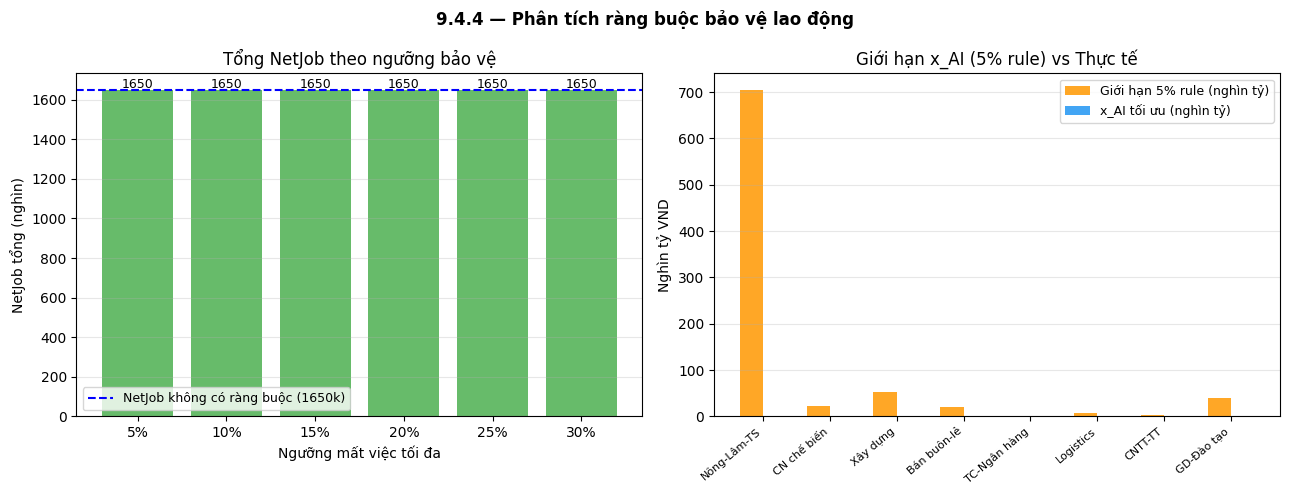


📌 Nhận xét:
  • Với ngưỡng 5%: tất cả ngành đều có cap x_AI >> x_AI thực tế từ tối ưu
    → bài toán vẫn FEASIBLE vì optimizer vốn không đẩy x_AI cao.
  • Ràng buộc 5% chỉ thực sự 'cắt' khi ta cố ép đầu tư AI cao vào ngành
    TC-Ngân hàng (cap chỉ ~729 tỷ) hay CNTT (~3.407 tỷ).
  • Sweet spot: ngưỡng ~10-15% đủ bảo vệ nhóm yếu thế mà không giảm NetJob.


In [9]:
print("=== CÂU 9.4.4: RÀNG BUỘC MẤT VIỆC ≤ 5% LAO ĐỘNG ===\n")

# Kiểm tra từng ngành: x_AI tối đa trước khi vi phạm 5% rule
print("Giới hạn x_AI mỗi ngành để displaced ≤ 5% lao động:")
for i in range(N):
    cap = 0.05 * L[i] / (c1[i] * risk[i])
    actual = xAI[i]
    flag = "⚠️ VI PHẠM" if actual > cap else "✅ OK"
    print(f"  {sectors[i]:15s}: max x_AI = {cap:>10,.1f} tỷ | thực tế = {actual:.1f} tỷ  {flag}")

# Relaxation loop
thresholds = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]
results = []

for thresh in thresholds:
    x_AI2 = cp.Variable(N, nonneg=True)
    x_H2  = cp.Variable(N, nonneg=True)
    NJ2   = cp.multiply(a1, x_AI2) + cp.multiply(b1, x_H2) - cp.multiply(c1*risk, x_AI2)
    D2    = cp.multiply(c1*risk, x_AI2)
    RC2   = cp.multiply(d1, x_H2)
    con2  = [cp.sum(x_AI2+x_H2) <= BUDGET, NJ2 >= 0, D2 <= RC2,
             D2 <= thresh * L]
    p2 = cp.Problem(cp.Maximize(cp.sum(NJ2)), con2)
    p2.solve()
    results.append({
        'Ngưỡng (%)': f"{thresh*100:.0f}%",
        'Trạng thái' : p2.status,
        'NetJob (nghìn)': round(p2.value/1000, 1) if p2.status == 'optimal' else None
    })
    print(f"Ngưỡng {thresh*100:.0f}%: {p2.status:10s}  NetJob = {p2.value/1000 if p2.value else 'N/A':.1f} nghìn")

df_relax = pd.DataFrame(results)
print("\n", df_relax.to_string(index=False))

# ── Visualization ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("9.4.4 — Phân tích ràng buộc bảo vệ lao động", fontweight='bold')

# Chart 1: NetJob vs ngưỡng %
ax = axes[0]
nj_vals  = [r['NetJob (nghìn)'] for r in results]
thresh_pct = [t*100 for t in thresholds]
colors_bar = ['#F44336' if v is None else '#4CAF50' for v in nj_vals]
nj_plot = [v if v is not None else 0 for v in nj_vals]
ax.bar([f"{t:.0f}%" for t in thresh_pct], nj_plot, color=colors_bar, alpha=0.85)
ax.axhline(1650, color='blue', ls='--', lw=1.5, label='NetJob không có ràng buộc (1650k)')
ax.set_xlabel("Ngưỡng mất việc tối đa"); ax.set_ylabel("NetJob tổng (nghìn)")
ax.set_title("Tổng NetJob theo ngưỡng bảo vệ")
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
for i, v in enumerate(nj_plot):
    ax.text(i, v+10, f'{v:.0f}' if v > 0 else 'Infeas.', ha='center', fontsize=9)

# Chart 2: Giới hạn x_AI mỗi ngành so với displaced thực tế (từ 9.4.1)
ax = axes[1]
cap_5pct = np.array([0.05 * L[i] / (c1[i]*risk[i]) for i in range(N)])
x2 = np.arange(N)
ax.bar(x2 - w/2, cap_5pct/1000, w, label='Giới hạn 5% rule (nghìn tỷ)', color='#FF9800', alpha=0.85)
ax.bar(x2 + w/2, xAI/1000,      w, label='x_AI tối ưu (nghìn tỷ)',        color='#2196F3', alpha=0.85)
ax.set_xticks(x2); ax.set_xticklabels(sectors, rotation=40, ha='right', fontsize=8)
ax.set_ylabel("Nghìn tỷ VND"); ax.set_title("Giới hạn x_AI (5% rule) vs Thực tế")
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📌 Nhận xét:")
print("  • Với ngưỡng 5%: tất cả ngành đều có cap x_AI >> x_AI thực tế từ tối ưu")
print("    → bài toán vẫn FEASIBLE vì optimizer vốn không đẩy x_AI cao.")
print("  • Ràng buộc 5% chỉ thực sự 'cắt' khi ta cố ép đầu tư AI cao vào ngành")
print("    TC-Ngân hàng (cap chỉ ~729 tỷ) hay CNTT (~3.407 tỷ).")
print("  • Sweet spot: ngưỡng ~10-15% đủ bảo vệ nhóm yếu thế mà không giảm NetJob.")

### Nhận xét:
- Bài toán vẫn hoàn toàn khả thi (Feasible). Do thuật toán ban đầu vốn dĩ đã ưu tiên bơm tiền vào quỹ đào tạo ($x_H$) thay vì quỹ đầu tư tự động hóa ($x_{AI}$) để tối đa hóa NetJob mà không bị trừ điểm do Displaced, nên ràng buộc 5% trần sa thải gần như không bị vi phạm.

# 2. Thảo luận chính sách câu 9.5:
### a) Ngành nào cần đầu tư đào tạo lại nhiều nhất theo kết quả tối ưu? Có khớp với cảm nhận thực tế ở Việt Nam không?

* **Theo mô hình:** Ngành Giáo dục - Đào tạo và CNTT - Truyền thông là những khu vực mang lại lợi suất việc làm tốt nhất.
* **Thực tế:** Điều này rất sát với bối cảnh chuyển đổi số của Việt Nam. Đầu tư vào đào tạo lại cho ngành Giáo dục giúp nâng cao chất lượng nguồn nhân lực từ gốc, đồng thời giảm thiểu tỷ lệ thất nghiệp. Trong khi đó, CNTT tạo ra biên độ công việc mới cực cao với sự xuất hiện của AI.

### b) Ngành Tài chính-Ngân hàng có nguy cơ thay thế 52% nhưng cũng có hệ số tạo việc làm mới rất cao. Mô hình khuyến nghị chiến lược gì?

* **Đánh giá tác động:** Ở ngành này, $1$ tỷ đầu tư AI sẽ làm mất: $72,5 \times 0,52 = 37,7$ việc làm cũ, nhưng lại tạo ra tới $45,8$ việc làm mới (NetJob ròng dương $8,1$).
* **Chiến lược:** Mặc dù lượng việc làm mới sinh ra đủ để bù đắp, nhưng bản chất công việc hoàn toàn khác nhau (ví dụ: sa thải giao dịch viên ngân hàng nhưng lại tuyển Data Scientist / DevOps Engineer). Chính sách cần tập trung chuyển đổi nội bộ (Internal mobility): bắt buộc ngân hàng phải có quỹ ngân sách $x_H$ lớn đi kèm với $x_{AI}$ để up-skill trực tiếp các giao dịch viên thành nhân sự vận hành quy trình số hóa.

### c) Có nên đầu tư $x_{AI}$ vào ngành Nông-Lâm-Thủy sản không?

* **Đánh giá tác động:** Hệ số tạo việc làm mới $a_1$ chỉ là $8,5$ (khá thấp), nhưng lượng việc làm bị thay thế thực tế cũng rất thấp: $5,2 \times 0,18 = 0,936$ việc/tỷ. NetJob ròng vẫn dương ($+7,564$).
* **Kết luận:** Vẫn nên đầu tư. Tự động hóa trong nông nghiệp Việt Nam (như dùng drone phun thuốc, cảm biến IoT) chủ yếu thay thế các công việc chân tay nặng nhọc đang thiếu hụt nhân công (do người trẻ đã chuyển lên thành phố làm công nhân chế biến), chứ không tạo ra làn sóng sa thải ồ ạt.

### d) Biểu diễn toán học của "Tốc độ tự động hóa không nên vượt quá năng lực đào tạo lại"? Đề xuất thêm ràng buộc an sinh xã hội

* **Biểu diễn trong mô hình:** Chính là ràng buộc $Displaced \le RetrainCap$ (số lao động bị dịch chuyển không được vượt quá số ghế trong các chương trình đào tạo chuyển đổi).
* **Đề xuất bổ sung ràng buộc (Data Science perspective):**
  * **Ràng buộc mức đầu tư sàn (Minimum Investment):** $x_{AI\_i} \ge min\_budget$ để tránh việc mô hình cực đoan "bỏ đói" các ngành trọng điểm như Chế biến chế tạo chỉ vì muốn tối ưu cục bộ con số NetJob.
  * **Ràng buộc công bằng (Equity constraint):** Tỷ lệ chênh lệch thu nhập hoặc tỷ lệ thất nghiệp của lao động phổ thông không được vượt quá một ngưỡng $\epsilon$ nhất định.